In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_excel('/content/Online Retail.xlsx')

In [ ]:
#dropping duplicates
df = df.drop_duplicates()

#remove rows missing indentifiers
df = df.dropna(subset=['CustomerID'])

#removing zeroes/negatives
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

#correcting data types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype(int).astype(str)

#creating total sales column for monetary feature
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

print(f"Cleaned dataset shape: {df.shape}")

Cleaned dataset shape: (392692, 9)


In [ ]:
print(df.head)

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice Custome

Building the cohort matrix.

In [ ]:
#creating invoice month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

#finding cohort month
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')

#creating cohort index
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')
year_diff = invoice_year - cohort_year
month_diff = invoice_month - cohort_month

#cohort index represent the month number( 0=first momth, 1=second month)
df['CohortIndex'] = year_diff * 12 + month_diff

In [ ]:
# Group by CohortMonth and CohortIndex, then count unique CustomerIDs
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()

# Pivot the data to create a matrix view
cohort_matrix = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

print(cohort_matrix)

CohortIndex     0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                  
2010-12      885.0  324.0  286.0  340.0  321.0  352.0  321.0  309.0  313.0   
2011-01      417.0   92.0  111.0   96.0  134.0  120.0  103.0  101.0  125.0   
2011-02      380.0   71.0   71.0  108.0  103.0   94.0   96.0  106.0   94.0   
2011-03      452.0   68.0  114.0   90.0  101.0   76.0  121.0  104.0  126.0   
2011-04      300.0   64.0   61.0   63.0   59.0   68.0   65.0   78.0   22.0   
2011-05      284.0   54.0   49.0   49.0   59.0   66.0   75.0   27.0    NaN   
2011-06      242.0   42.0   38.0   64.0   56.0   81.0   23.0    NaN    NaN   
2011-07      188.0   34.0   39.0   42.0   51.0   21.0    NaN    NaN    NaN   
2011-08      169.0   35.0   42.0   41.0   21.0    NaN    NaN    NaN    NaN   
2011-09      299.0   70.0   90.0   34.0    NaN    NaN    NaN    NaN    NaN   
2011-10      358.0   86.0   41.0    NaN    NaN    NaN    NaN    

In [ ]:
#extract the initial cohort size(month 0 column)
cohort_sizes = cohort_matrix.iloc[:, 0]

#divide the entire matrix by the cohort size column along the rows(axis = 0)
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

#round it to look neat
retention_matrix = retention_matrix.round(3)
print(retention_matrix)


CohortIndex   0      1      2      3      4      5      6      7      8   \
CohortMonth                                                                
2010-12      1.0  0.366  0.323  0.384  0.363  0.398  0.363  0.349  0.354   
2011-01      1.0  0.221  0.266  0.230  0.321  0.288  0.247  0.242  0.300   
2011-02      1.0  0.187  0.187  0.284  0.271  0.247  0.253  0.279  0.247   
2011-03      1.0  0.150  0.252  0.199  0.223  0.168  0.268  0.230  0.279   
2011-04      1.0  0.213  0.203  0.210  0.197  0.227  0.217  0.260  0.073   
2011-05      1.0  0.190  0.173  0.173  0.208  0.232  0.264  0.095    NaN   
2011-06      1.0  0.174  0.157  0.264  0.231  0.335  0.095    NaN    NaN   
2011-07      1.0  0.181  0.207  0.223  0.271  0.112    NaN    NaN    NaN   
2011-08      1.0  0.207  0.249  0.243  0.124    NaN    NaN    NaN    NaN   
2011-09      1.0  0.234  0.301  0.114    NaN    NaN    NaN    NaN    NaN   
2011-10      1.0  0.240  0.115    NaN    NaN    NaN    NaN    NaN    NaN   
2011-11     

Using the mask parameter to hide the nan values, so the heatmap looks clean.

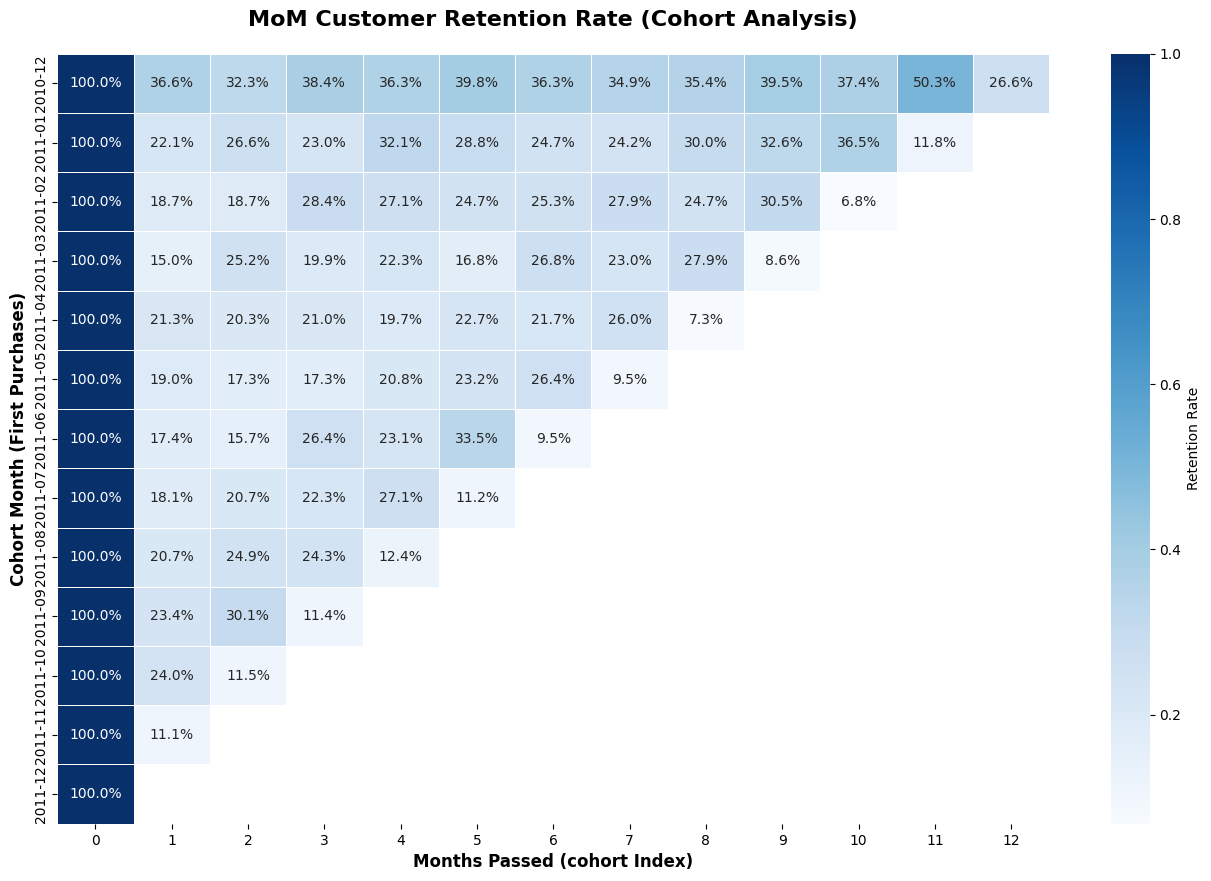

In [ ]:
#create a mask to hide nan values
mask = retention_matrix.isnull()

plt.figure(figsize=(16, 10))
plt.title('MoM Customer Retention Rate (Cohort Analysis)', fontsize=16, fontweight='bold', pad=20)

sns.heatmap(
    data=retention_matrix,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    mask=mask,   #this hides the nan values from the visual grid
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate'}
)

plt.ylabel('Cohort Month (First Purchases)', fontsize=12, fontweight='bold')
plt.xlabel('Months Passed (cohort Index)', fontsize=12, fontweight='bold')
plt.show()

Since this dataset is historical (ending in December 2011), calculating "Recency" based on today's current date would make everyone look like they haven't purchased in over a decade. Instead, we pretend we are analyzing the data exactly one day after the absolute last invoice in the dataset.

In [14]:
import datetime as dt

#define snapshot date(1 day after the maximum date in the dataset)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

#group by customerid and aggregate metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  #recency
    'InvoiceNo': 'nunique',                                   #frequency(unique orders)
    'TotalSales': 'sum'                                       #monetary(total spend)
})

#rename columns for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSales': 'Monetary'
}, inplace=True)

print(rfm.head())
print(rfm.describe())



            Recency  Frequency  Monetary
CustomerID                              
12346           326          1  77183.60
12347             2          7   4310.00
12348            75          4   1797.24
12349            19          1   1757.55
12350           310          1    334.40
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2048.688081
std     100.014169     7.697998    8985.230220
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     306.482500
50%      51.000000     2.000000     668.570000
75%     142.000000     5.000000    1660.597500
max     374.000000   209.000000  280206.020000


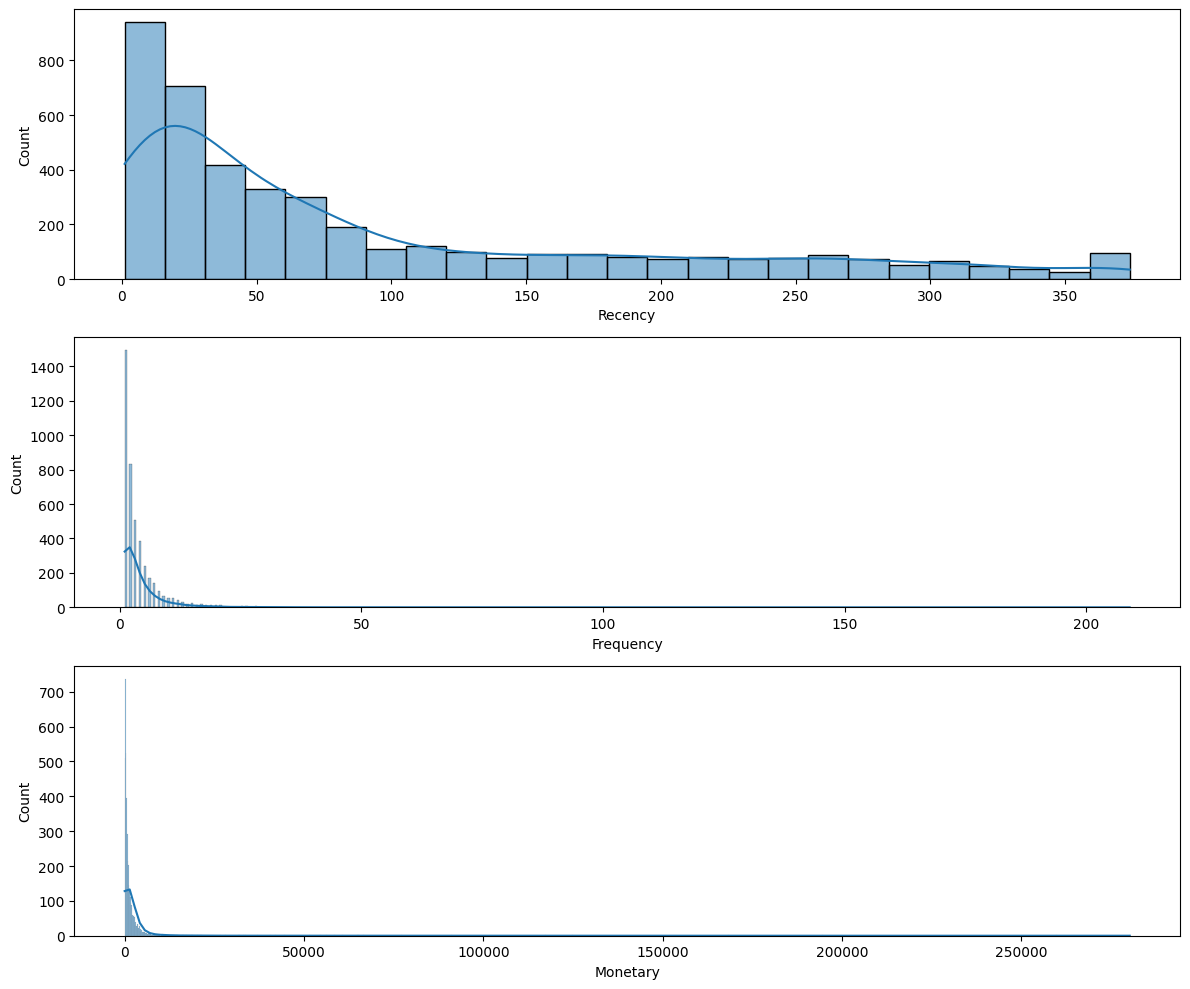

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of Recency, Frequency, and Monetary
plt.figure(figsize=(12,10))

plt.subplot(3, 1, 1); sns.histplot(rfm['Recency'], kde=True)
plt.subplot(3, 1, 2); sns.histplot(rfm['Frequency'], kde=True)
plt.subplot(3, 1, 3); sns.histplot(rfm['Monetary'], kde=True)

plt.tight_layout()
plt.show()

The Skewness: Look at Monetary. The average (mean) spend is around $2049, but the maximum is an astronomical $280,206. Meanwhile the 75th percentile is only $1661. This means you have major outliers stretcning the data.

Scale Differences: Recency values go up to 374 days, while Frequency values mostly sit between 1 and 5. If you pass this directly into K-Means, the algorithm will completely ignore Frequency because its numerical scale is tiny compared to Recency and Monetary.

To fix this and make it ready for K-Means, we must perform a standard data science preprocessing workflow: Log Transformation followed by Standard Scaling.

In [15]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Apply log transformation to handle right-skewness
# We use log1p (log(1+x)) as a safe habit in case there are 0 or negative values anywhere, though our cleaning avoided it
rfm_log = np.log(rfm)

# 2. Initialize and apply StandardScaler
scaler = StandardScaler()
scaler.fit(rfm_log)

# 3. Transform the data into a clean, scaled numpy array and convert back to DataFrame
rfm_scaled = scaler.transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

# Let's see the normalized, un-skewed data
print(rfm_scaled_df.head())

             Recency  Frequency  Monetary
CustomerID                               
12346       1.409894  -1.048610  3.700201
12347      -2.146498   1.111836  1.413256
12348       0.383971   0.490522  0.719951
12349      -0.574674  -1.048610  0.702251
12350       1.374758  -1.048610 -0.612996


The Elbow Method (Finding the Perfect Number of Clusters)Now that the data is normalized, how many customer groups ($K$) should we create? 3? 4? 5? Instead of guessing, we use the Elbow Method. We will run K-Means multiple times with different cluster amounts and calculate the Within-Cluster Sum of Squares (WCSS) or inertia.

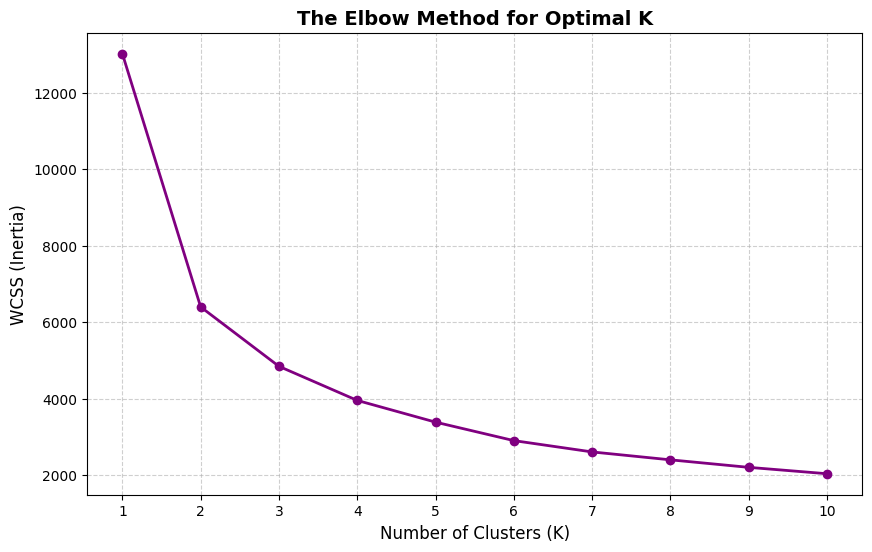

In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Dictionary to hold our metric values (Within-Cluster Sum of Squares)
wcss = {}

# Test numbers of clusters from 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss[k] = kmeans.inertia_  # Inertia is the WCSS value

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
# Using 'marker' instead of 'point' fixes the error
plt.plot(list(wcss.keys()), list(wcss.values()), marker='o', color='purple', linewidth=2)

plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [19]:
from sklearn.cluster import KMeans

#initialize kmeans with 3 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)

#fit and predict on the scaled dataframe
cluster_labels = kmeans.fit_predict(rfm_scaled_df)

#assign the cluster labels back to our original unscaled rfm dataframe
rfm_assigned = rfm.copy()
rfm_assigned['Cluster'] = cluster_labels

print(rfm_assigned.head())


            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12346           326          1  77183.60        2
12347             2          7   4310.00        0
12348            75          4   1797.24        2
12349            19          1   1757.55        2
12350           310          1    334.40        1


The business breakdown: figuring out what these groups represent.

In [22]:
#group by cluster and calculate average metrics
cluster_analysis = rfm_assigned.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Customer_count'}).round(1)

print(cluster_analysis)

         Recency  Frequency  Monetary  Customer_count
Cluster                                              
0           13.3       13.0    7608.2             781
1          161.3        1.3     339.5            1862
2           53.5        3.5    1364.6            1695


Recency: low recency is good (gap b/w the last transaction from the day of calculation)
Frequency: should be high (no. of unique transactions made)
Monetary:  also good if high.(total spending by an unique customer)

Cluster 0: These are the absolute rockstars. Even though they represent the smallest group by headcount (814 people), they are your heavy hitters. They shop constantly, spend massive amounts of money, and were active less than two weeks ago.

Cluster 1: This is a large, stagnant pool of customers. They came, spent very little money, bought maybe once or twice, and haven't been seen in nearly 5 months. They have likely churned or were just one-time holiday shoppers.

Cluster 2: This is the largest customer group! They are relatively fresh, have moderate spending habits, and have returned to buy at least a second time. They aren't VIPs yet, but they have the momentum to get there.

the snake plot: visualizing how the clusters split across the metrics.

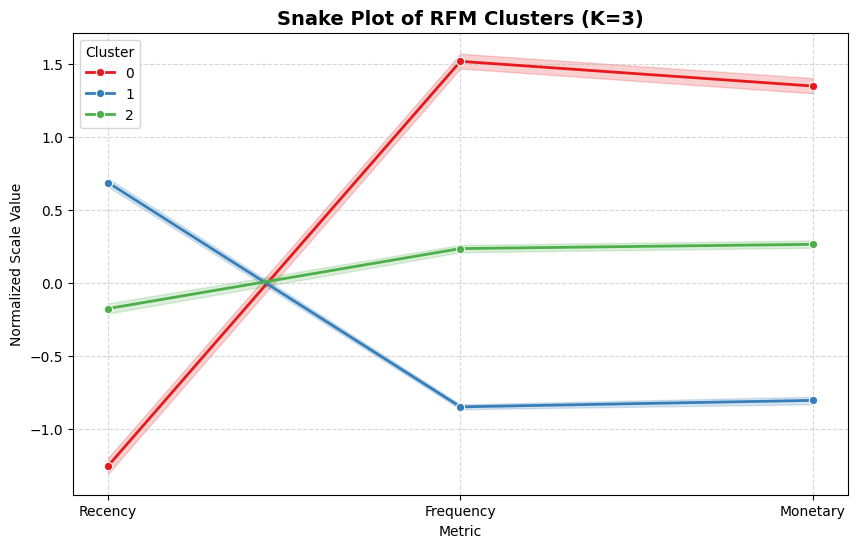

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Prepare scaled data for plotting
rfm_scaled_df['Cluster'] = cluster_labels
rfm_melted = pd.melt(rfm_scaled_df.reset_index(),
                     id_vars=['CustomerID', 'Cluster'],
                     value_vars=['Recency', 'Frequency', 'Monetary'],
                     var_name='Metric',
                     value_name='Value')

# Plotting
plt.figure(figsize=(10, 6))
plt.title('Snake Plot of RFM Clusters (K=3)', fontsize=14, fontweight='bold')
sns.lineplot(x='Metric', y='Value', hue='Cluster', data=rfm_melted, palette='Set1', marker='o', linewidth=2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylabel('Normalized Scale Value')
plt.show()